In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error ,mean_squared_error

In [2]:
!pip install finance


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for finance: filename=finance-0.2502-py3-none-any.whl size=46536 sha256=ae967a8710a688b1a338d66be9bb57c116460697d5265ed1c97d12bdeae8918e
  Stored in directory: /root/.cache/pip/wheels/70/58/59/315360d321841a98cc3bc280bea6f30c3f310c92e3a47ffdba
Successfully built finance


In [3]:
import yfinance as yf
ticker="AAPL"

df=yf.download( ticker , start="2020-01-01", end="2025-12-31", progress=False)

df


/tmp/ipython-input-4239958671.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download( ticker , start="2020-01-01", end="2025-12-31", progress=False)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.468262,72.528582,71.223259,71.476600,135480400
2020-01-03,71.763725,72.523754,71.539337,71.696167,146322800
2020-01-06,72.335548,72.374154,70.634532,70.885464,118387200
2020-01-07,71.995369,72.600975,71.775804,72.345220,108872000
2020-01-08,73.153481,73.455080,71.698566,71.698566,132079200
...,...,...,...,...,...
2025-12-23,272.359985,272.500000,269.559998,270.839996,29642000
2025-12-24,273.809998,275.429993,272.200012,272.339996,17910600


In [4]:
series=df['Close'].squeeze()
series.index=pd.to_datetime(series.index)
series , type(series)


(Date
 2020-01-02     72.468262
 2020-01-03     71.763725
 2020-01-06     72.335548
 2020-01-07     71.995369
 2020-01-08     73.153481
                  ...    
 2025-12-23    272.359985
 2025-12-24    273.809998
 2025-12-26    273.399994
 2025-12-29    273.760010
 2025-12-30    273.079987
 Name: AAPL, Length: 1507, dtype: float64,
 pandas.core.series.Series)

In [5]:
series=series.asfreq('B')
# B is keyword here , represents bussiness day frequency
series=series.fillna(method='ffill')

#we are not including weekends .
#Continuous != calendar-continuous


/tmp/ipython-input-324543156.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series=series.fillna(method='ffill')


In [6]:
series


,AAPL
Date,
2020-01-02,72.468262
2020-01-03,71.763725
2020-01-06,72.335548
2020-01-07,71.995369
2020-01-08,73.153481
...,...
2025-12-24,273.809998
2025-12-25,273.809998
2025-12-26,273.399994


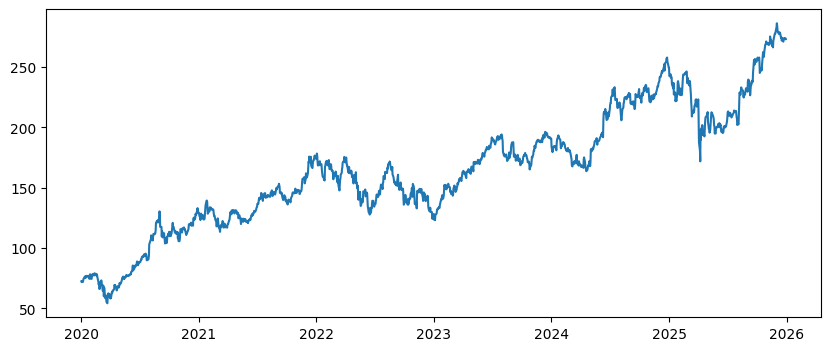

In [7]:
plt.figure(figsize=(10,4))
plt.plot(series)


In [8]:
from statsmodels.tsa.stattools import adfuller
adfuller(series)
#stationarity test

(np.float64(-0.6594190526647683),
 np.float64(0.8569828361339236),
 10,
 1553,
 {'1%': np.float64(-3.4345677345088688),
  '5%': np.float64(-2.8634028737525887),
  '10%': np.float64(-2.5677617635268795)},
 np.float64(7703.427466743267))

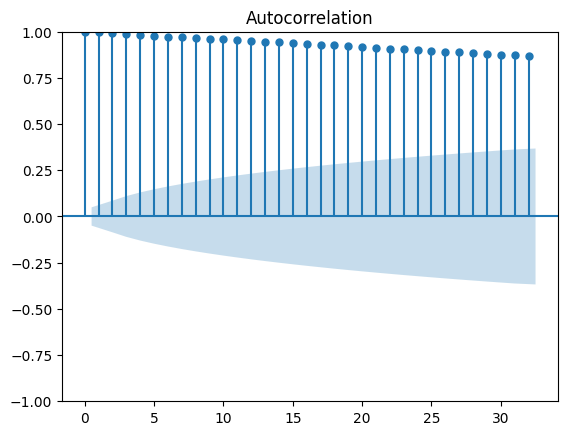

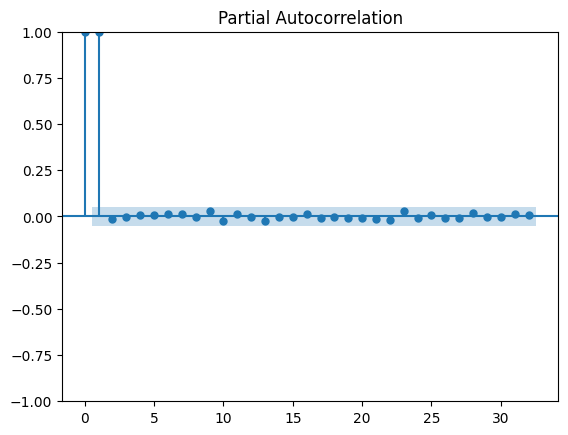

In [9]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

pacf=plot_acf(series)
acf=plot_pacf(series)

In [10]:
#initially the given data is non stationary with a upward trend , so by taking first differnce , the mean and volatility becomes constant
#doing this because time series model needs stationary data to work upon

In [11]:
series_first_diff=series.diff().dropna()

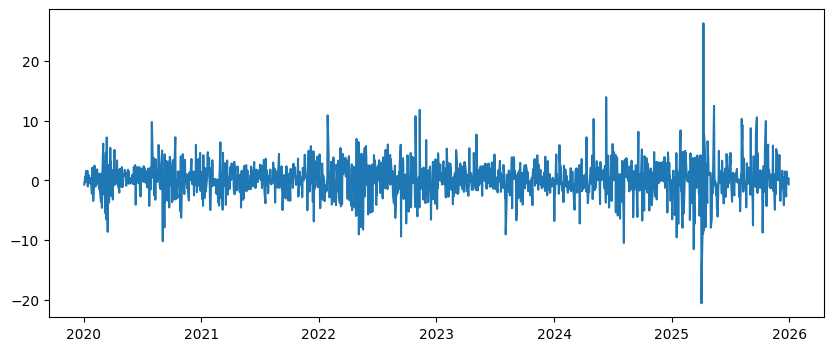

In [12]:
plt.figure(figsize=(10,4))
plt.plot(series_first_diff)

#after difference the data

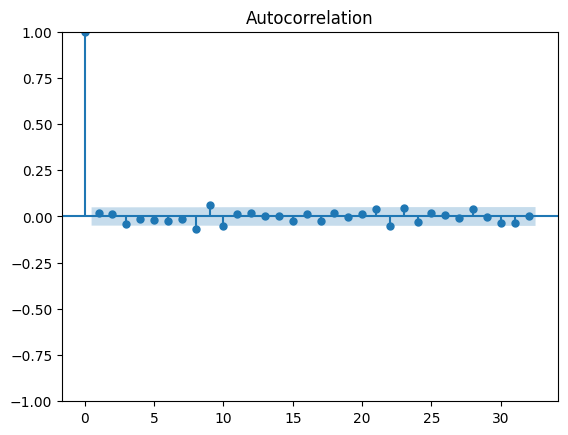

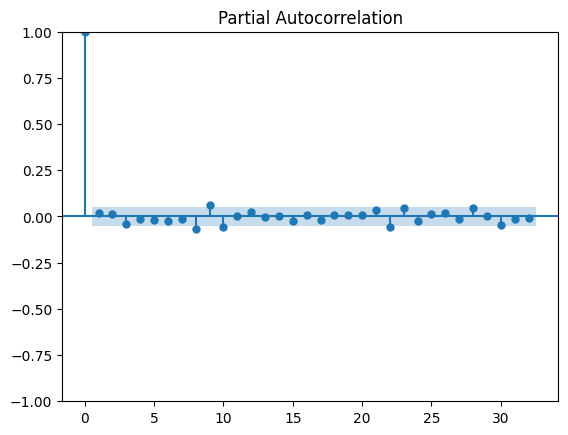

In [13]:
acf=plot_acf(series_first_diff)
pacf=plot_pacf(series_first_diff)

In [14]:
adfuller(series_first_diff)
#stationary- non stationary test
#p value < 0.05 means stationary

(np.float64(-13.751021584385192),
 np.float64(1.0505151446966298e-25),
 9,
 1553,
 {'1%': np.float64(-3.4345677345088688),
  '5%': np.float64(-2.8634028737525887),
  '10%': np.float64(-2.5677617635268795)},
 np.float64(7697.846174091298))

In [15]:
train_size=int(len(series)*0.8)

X_train=series.iloc[:train_size]
X_val=series.iloc[train_size:]
#.iloc completely ignores the index values.
#It works only on position, exactly like a Python list.
#.iloc is positionalbased but .loc is labeled based
X_train , X_val

(Date
 2020-01-02     72.468262
 2020-01-03     71.763725
 2020-01-06     72.335548
 2020-01-07     71.995369
 2020-01-08     73.153481
                  ...    
 2024-10-11    226.276535
 2024-10-14    230.005554
 2024-10-15    232.541275
 2024-10-16    230.482849
 2024-10-17    230.850784
 Freq: B, Name: AAPL, Length: 1251, dtype: float64,
 Date
 2024-10-18    233.684830
 2024-10-21    235.156555
 2024-10-22    234.540039
 2024-10-23    229.468567
 2024-10-24    229.279633
                  ...    
 2025-12-24    273.809998
 2025-12-25    273.809998
 2025-12-26    273.399994
 2025-12-29    273.760010
 2025-12-30    273.079987
 Freq: B, Name: AAPL, Length: 313, dtype: float64)

In [16]:
rolling_preds=[]


for date in X_val.index:
    model=SARIMAX(X_train , order=(1,1,1) , enforce_stationarity=False,
                  enforce_invertibility=False)




    model_fit=model.fit()
    pred=model_fit.forecast(steps=1)
    rolling_preds.append(pred.iloc[0])
    #if not iloc it'll would append a Series inside a list
    X_train.loc[date]=X_val.loc[date]

rolling_preds=pd.Series(rolling_preds, index=X_val.index)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

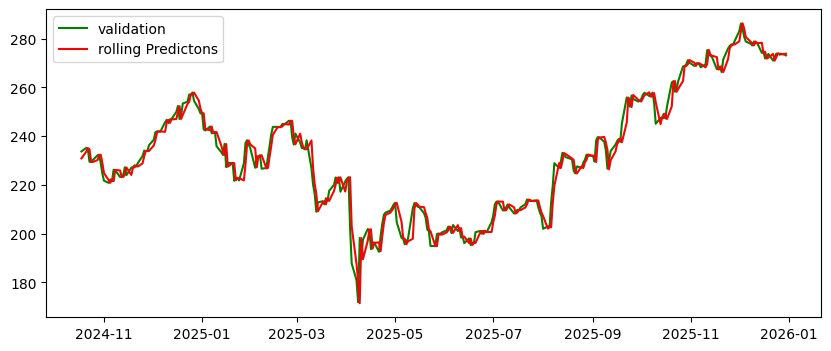

In [17]:
plt.figure(figsize=(10,4))
plt.plot(X_train,label="training" , color="blue")
plt.plot(X_val , label="validation" , color="green")
plt.plot(rolling_preds, label="rolling Predictons" , color="red")
plt.legend()

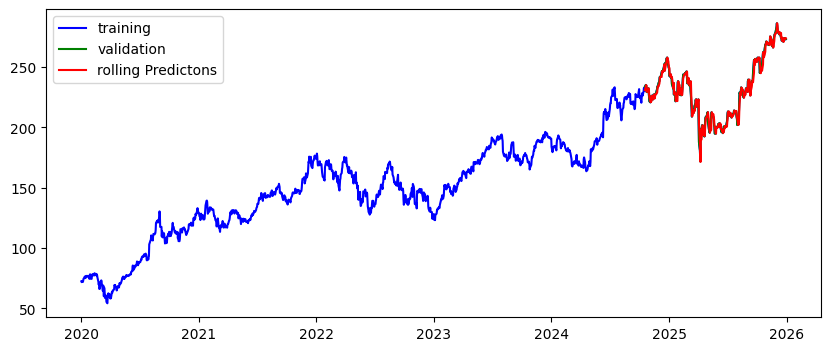

In [18]:
plt.figure(figsize=(10,4))
plt.plot(X_train,label="training" , color="blue")
plt.plot(X_val , label="validation" , color="green")
plt.plot(rolling_preds, label="rolling Predictons" , color="red")
plt.legend()

In [19]:
mean=mean_absolute_error(X_val , rolling_preds)
rmse=np.sqrt(mean_squared_error(X_val , rolling_preds))
print(f" Validation MAE: {mean}")
print(f" validation RMSE : {rmse}")



 Validation MAE: 2.6031855965034185
 validation RMSE : 3.998406905084618


In [20]:
from datetime import timedelta
from datetime import datetime

In [21]:
final_model=SARIMAX(series , order=(1,1,1), enforce_stationarity=False ,
                    enforce_invertibility=False)
final_fit=final_model.fit()

forecast_price=final_fit.forecast(steps=7)
forecast_result=final_fit.get_forecast(steps=7)


forecast_mean=forecast_result.predicted_mean

conf_int=forecast_result.conf_int()

forecast_price

#rolling forecast is also giving same , so using this directly

,predicted_mean
2025-12-31,273.067873
2026-01-01,273.066073
2026-01-02,273.065805
2026-01-05,273.065765
2026-01-06,273.065759
2026-01-07,273.065758
2026-01-08,273.065758


In [22]:
forecast_price

,predicted_mean
2025-12-31,273.067873
2026-01-01,273.066073
2026-01-02,273.065805
2026-01-05,273.065765
2026-01-06,273.065759
2026-01-07,273.065758
2026-01-08,273.065758


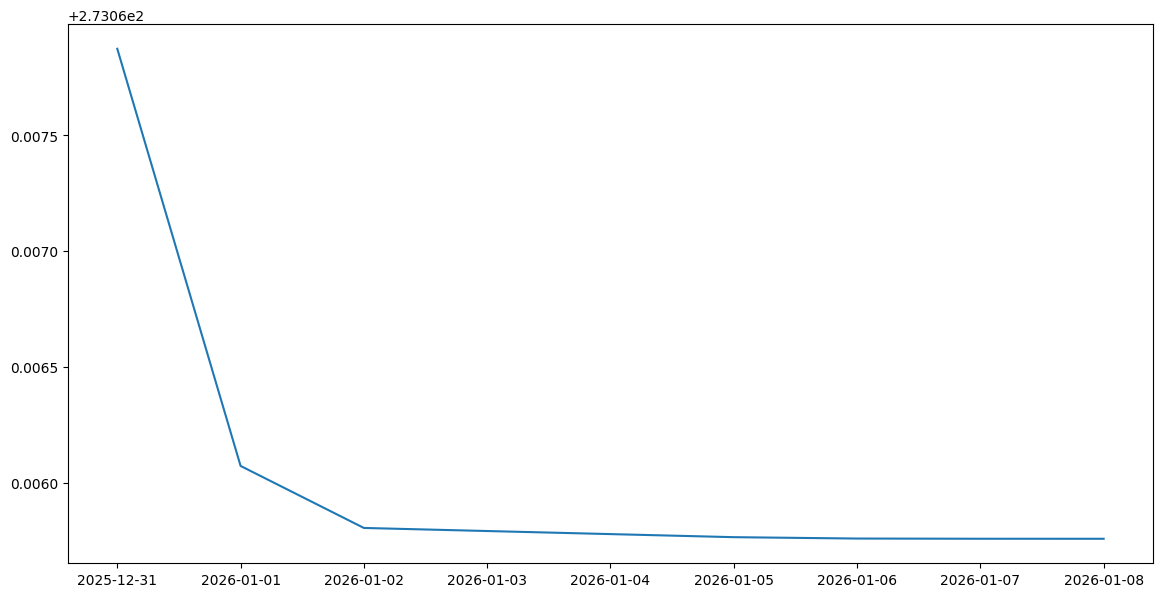

In [23]:
plt.figure(figsize=(14,7))
plt.plot(forecast_price , label="forecast_price")

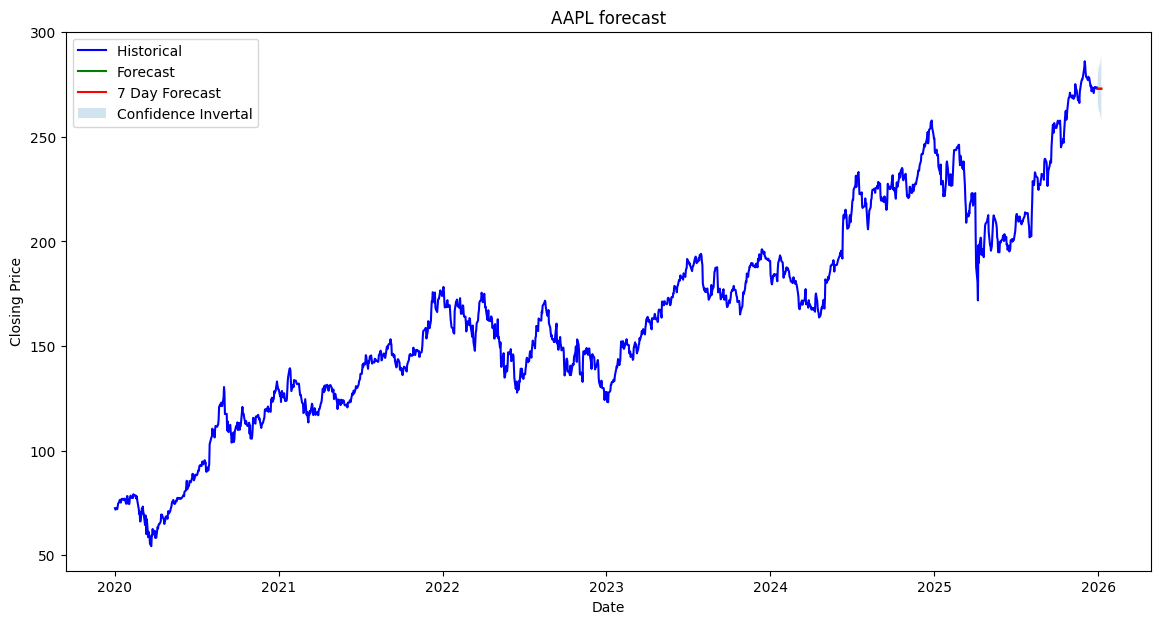

In [24]:
plt.figure(figsize=(14,7))
plt.plot(series, label="Historical " , color="blue")
plt.plot(forecast_price , label="Forecast" ,color="green")
plt.plot(forecast_mean,label="7 Day Forecast", color="red")
plt.fill_between(conf_int.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 alpha=0.2,
                 label="Confidence Invertal")
plt.legend()
plt.title(f"AAPL forecast")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

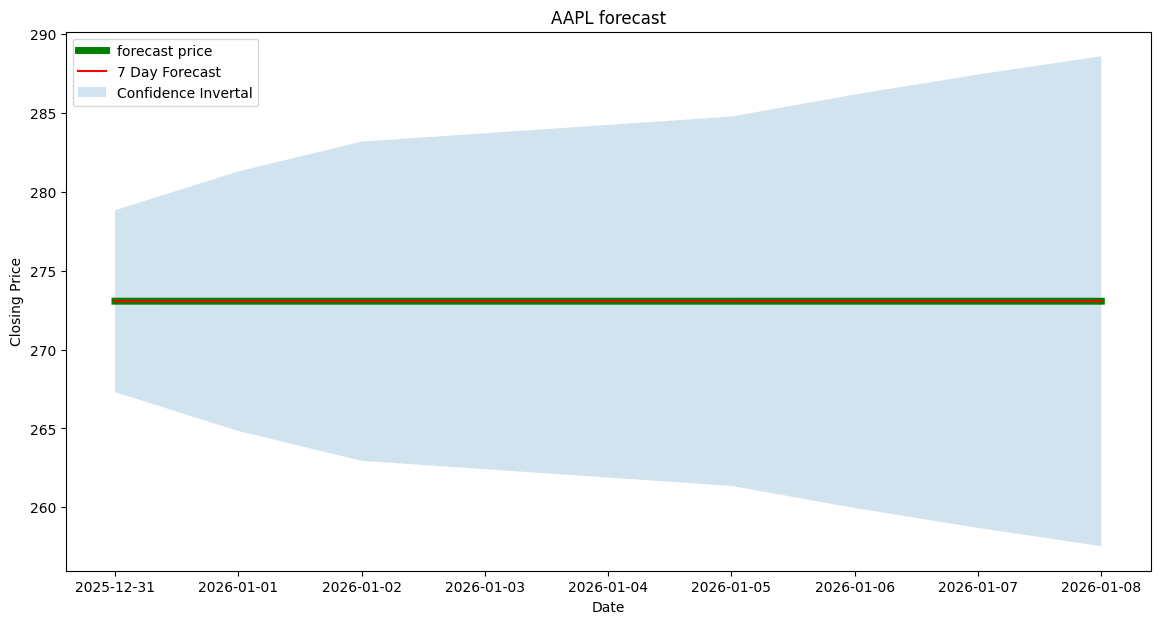

In [25]:
plt.figure(figsize=(14,7))
plt.plot(forecast_price , label="forecast price", color="green", linewidth=5)
plt.plot(forecast_mean,label="7 Day Forecast", color="red")
plt.fill_between(conf_int.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 alpha=0.2,
                 label="Confidence Invertal")
plt.legend()
plt.title(f"AAPL forecast")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

In [26]:
residuals=rolling_preds-X_val
residuals

,0
Date,
2024-10-18,-2.840736
2024-10-21,-1.563606
2024-10-22,0.532251
2024-10-23,5.053580
2024-10-24,0.338092
...,...
2025-12-24,-1.430043
2025-12-25,0.030127
2025-12-26,0.413916


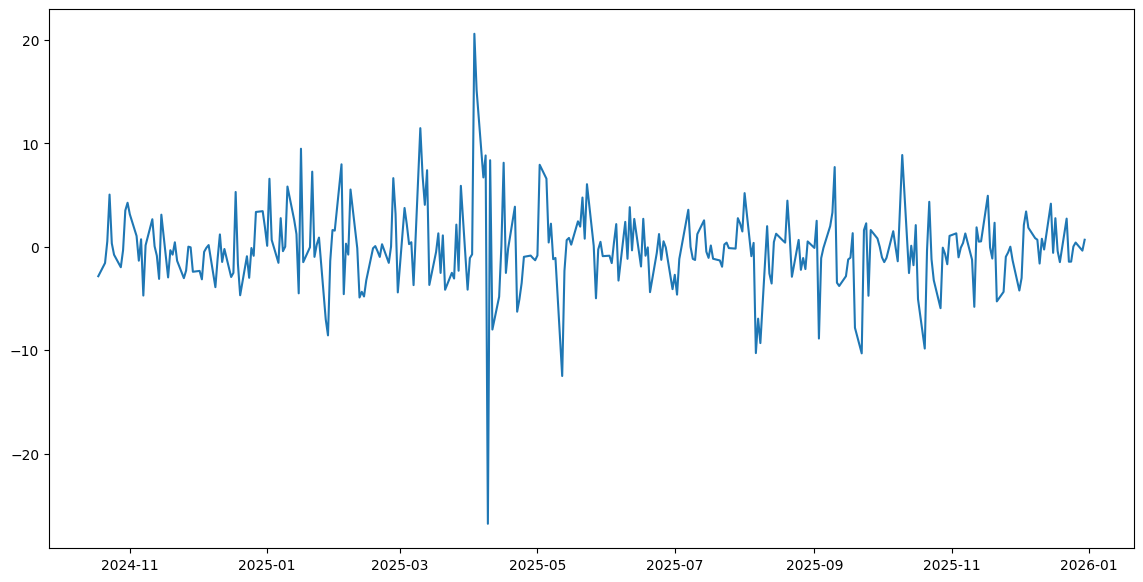

In [27]:
plt.figure(figsize=(14,7))
plt.plot(residuals)
plt.show()

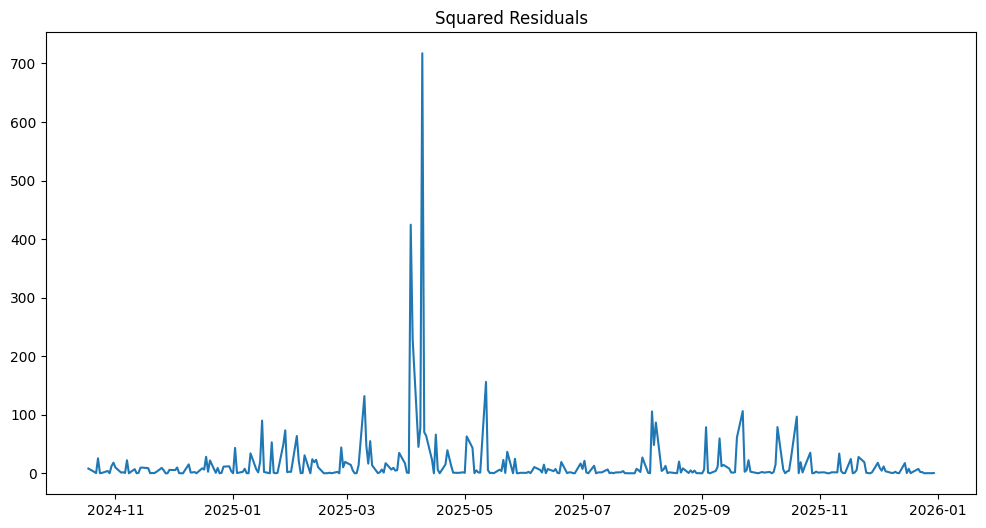

In [38]:
plt.figure(figsize=(12,6))
plt.plot(residuals**2)
plt.title('Squared Residuals')
plt.show()
#volatility check

In [39]:
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(residuals)
print('ARCH-LM Test Statistic:', arch_test[0])
print('p-value:', arch_test[1])
#to check if we should use garch model

ARCH-LM Test Statistic: 59.722065509932946
p-value: 4.090703210280944e-09


In [30]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 15.2 MB/s eta 0:00:00


In [31]:
from arch import arch_model
model=arch_model(residuals , vol="Garch" , p=1 , q=1)
model_fit=model.fit()
print(model_fit.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 1434.1946565196408
Iteration:      2,   Func. Count:     14,   Neg. LLF: 1193.3400158895408
Iteration:      3,   Func. Count:     21,   Neg. LLF: 860.5138784799342
Iteration:      4,   Func. Count:     28,   Neg. LLF: 846.6667718415188
Iteration:      5,   Func. Count:     34,   Neg. LLF: 853.4203505260557
Iteration:      6,   Func. Count:     40,   Neg. LLF: 846.3147102534306
Iteration:      7,   Func. Count:     46,   Neg. LLF: 846.3101875064972
Iteration:      8,   Func. Count:     51,   Neg. LLF: 846.3101673044321
Iteration:      9,   Func. Count:     56,   Neg. LLF: 846.3101658655703
Iteration:     10,   Func. Count:     60,   Neg. LLF: 846.3101658655534
Optimization terminated successfully    (Exit mode 0)
            Current function value: 846.3101658655703
            Iterations: 10
            Function evaluations: 60
            Gradient evaluations: 10
                     Constant Mean - GARCH Model Results             

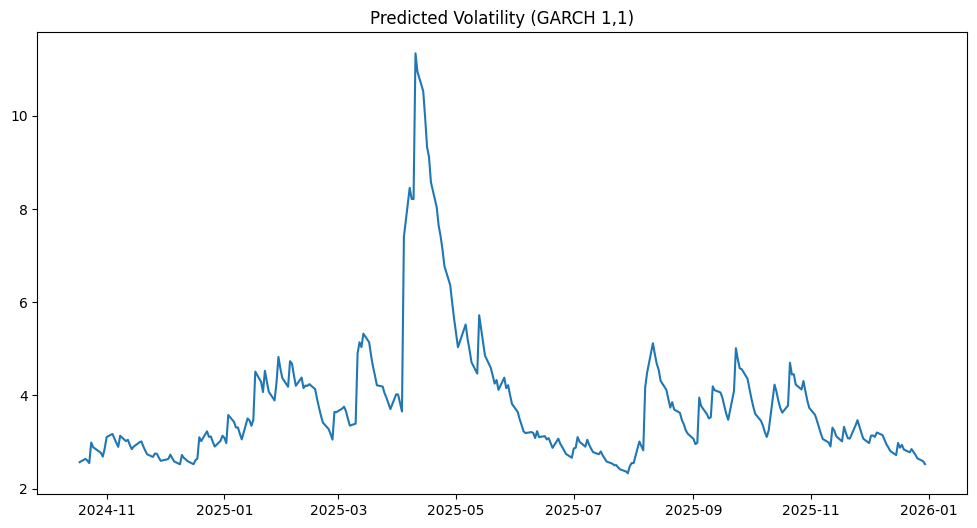

In [32]:
plt.figure(figsize=(12,6))
plt.plot(model_fit.conditional_volatility)
plt.title('Predicted Volatility (GARCH 1,1)')
plt.show()


In [33]:
# in finanical data volatility is measure of risk

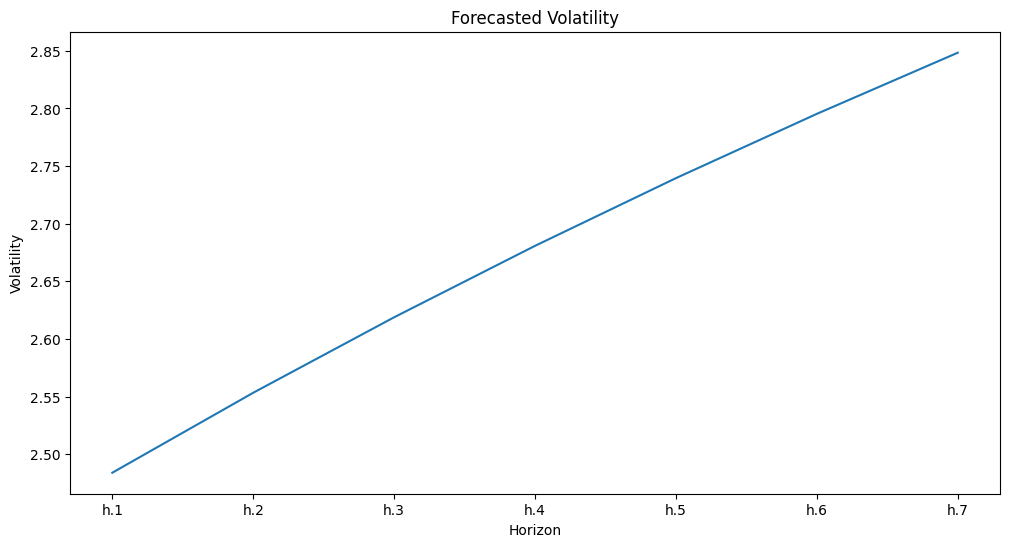

In [34]:
forecast_vol=model_fit.forecast(horizon=7)
plt.figure(figsize=(12,6))
plt.plot(np.sqrt(forecast_vol.variance.iloc[0]))
plt.title('Forecasted Volatility')
plt.xlabel('Horizon')
plt.ylabel('Volatility')
plt.show()